In [2]:
import os
import sys
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, './utils')

from utils import * 
from plotUtils import *
from fcMeasure import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [5]:
# Reading connectivity matrix from OSF data

root_data = "./data"

AALMAp = pd.read_csv("./data/AAL_regions.csv", sep=";")
ROI = AALMAp['ROI number'].to_numpy()
ROI_tags = AALMAp['ROI name'].to_numpy()

In [7]:
_scfiles = sorted(glob.glob(os.path.join(root_data, "S*.csv")))
print(f"No. of SC files = {len(_scfiles)}")

No. of SC files = 88


In [25]:
N = 90
meanA = np.zeros((N, N))

for _sc in _scfiles:
    A = pd.read_csv(_sc, header=None).to_numpy()
    A = (A + A.T) / 2                       # Symetrizes the matrices
    print(np.mean(A))
    meanA += (1 / len(_scfiles)) * A

0.006009369338864198
0.006680740151024691
0.007578961644135802
0.006034872841938272
0.007801183865432099
0.007758524850395062
0.007220528991358025
0.00800963333497531
0.006434804007938271
0.007135774281135803
0.0064919792211234565
0.006953304763530864
0.007299026667222222
0.006440911591851852
0.006963046642691358
0.006620063619395061
0.007167550941222222
0.007123811402481482
0.007253401426975309
0.0075428407755061735
0.0066929171437901235
0.006883177478777778
0.007165350091395062
0.006950807809592593
0.006847212109839506
0.0057684112476049385
0.007431748750679012
0.007226504343222223
0.007179319748283951
0.007244049662814815
0.006278871138555556
0.00716607397591358
0.007148153746074074
0.007253363936629629
0.008325497324555555
0.006913435770753087
0.007586935148987655
0.0060630536288765425
0.007387051606567901
0.008311906773481481
0.007493468403864198
0.008058156512333332
0.008058200788
0.0076616291055679004
0.0077301344755802475
0.007909242557567902
0.006427994878728395
0.006515497872

(0.0, 0.44964212382954544)

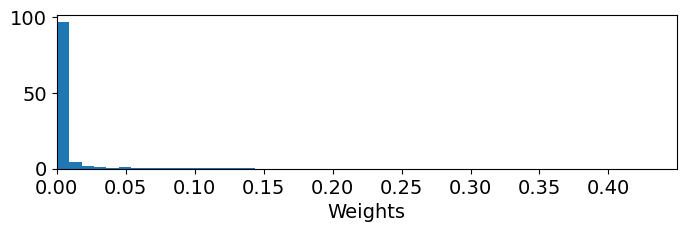

In [64]:
undirect_weights = meanA[np.triu_indices(N, k=1)]

# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(undirect_weights, bins=50, density=True, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(undirect_weights), np.max(undirect_weights))

Text(0.1, 50, 'Exponential distribution with $\\lambda = 100$')

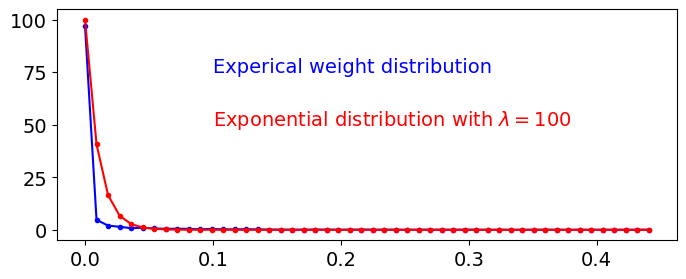

In [65]:
plt.figure(figsize=(8, 3))
plt.plot(h[1][:-1], h[0], '.-', color='blue')
plt.plot(h[1][:-1], 100 * np.exp(-100 * h[1][:-1]), '.-', color='red')
plt.text(0.1, 75, "Experical weight distribution", color='blue')
plt.text(0.1, 50, r"Exponential distribution with $\lambda = 100$", color='red')

In [66]:
# creating a sub graph from right hemisphere ROIs

RightROIs = ROI[1 :: 2] - 1
nNodes = 10

RandomROIS = RightROIs[15 : 15 + nNodes] # np.array(random.sample(list(RightROIs), k=nNodes))
RandomROI_tags = ROI_tags[RandomROIS]
meanAsub = meanA[RandomROIS, :][:, RandomROIS]

(6.338156818181818e-06, 0.3008163252284091)

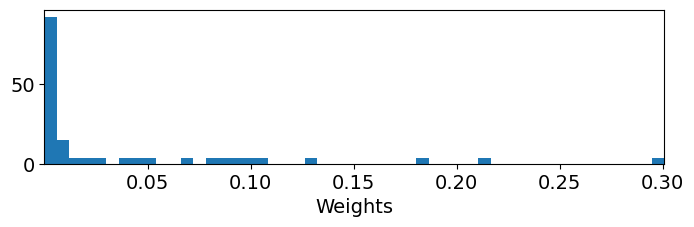

In [67]:
undirect_weights_sub = meanAsub[np.triu_indices(nNodes, k=1)]

# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(undirect_weights_sub, bins=50, density=True, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(undirect_weights_sub), np.max(undirect_weights_sub))

Text(0.1, 50, 'Exponential distribution with $\\lambda = 100$')

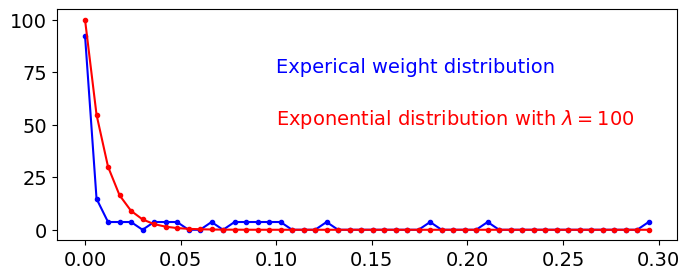

In [68]:
plt.figure(figsize=(8, 3))
plt.plot(h[1][:-1], h[0], '.-', color='blue')
plt.plot(h[1][:-1], 100 * np.exp(-100 * h[1][:-1]), '.-', color='red')
plt.text(0.1, 75, "Experical weight distribution", color='blue')
plt.text(0.1, 50, r"Exponential distribution with $\lambda = 100$", color='red')

In [69]:
# Scaling
normalization_factor = np.max(np.abs(meanAsub.sum(axis=1)))
meanAsub_norm = meanAsub / normalization_factor

(1.0582659977835008e-05, 0.5022654025444727)

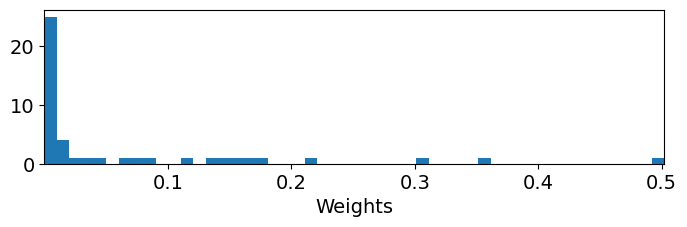

In [74]:
undirect_weights_sub = meanAsub_norm[np.triu_indices(nNodes, k=1)]

# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(undirect_weights_sub, bins=50, density=False, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(undirect_weights_sub), np.max(undirect_weights_sub))

Text(0.1, 30, 'Exponential distribution with $\\lambda = 50$')

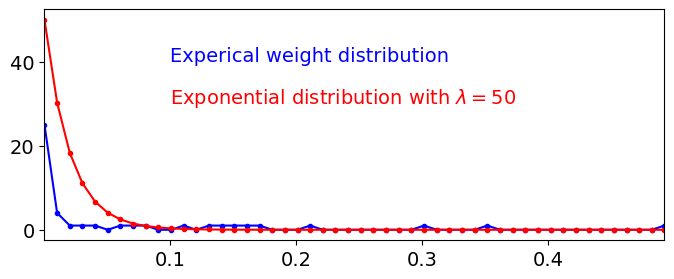

In [79]:
plt.figure(figsize=(8, 3))
plt.plot(h[1][:-1], h[0], '.-', color='blue')
plt.plot(h[1][:-1], 50 * np.exp(-50 * h[1][:-1]), '.-', color='red')
plt.xlim(h[1][0], h[1][-2])
plt.text(0.1, 40, "Experical weight distribution", color='blue')
plt.text(0.1, 30, r"Exponential distribution with $\lambda = 50$", color='red')

In [72]:
len(undirect_weights_sub)

45

In [73]:
h

(array([55.30614477,  8.84898316,  2.21224579,  2.21224579,  2.21224579,
         0.        ,  2.21224579,  2.21224579,  2.21224579,  0.        ,
         0.        ,  2.21224579,  0.        ,  2.21224579,  2.21224579,
         2.21224579,  2.21224579,  2.21224579,  0.        ,  0.        ,
         0.        ,  2.21224579,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         2.21224579,  0.        ,  0.        ,  0.        ,  0.        ,
         2.21224579,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  2.21224579]),
 array([1.05826600e-05, 1.00556791e-02, 2.01007755e-02, 3.01458719e-02,
        4.01909683e-02, 5.02360646e-02, 6.02811610e-02, 7.03262574e-02,
        8.03713538e-02, 9.04164502e-02, 1.00461547e-01, 1.10506643e-01,
        1.20551739e-01, 1.30596836e-01, 1.40641932e-